# Imports

In [1]:
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse
import heap

## Read in the .root file

In [2]:
data_file = "../test_data/20251020/pcap/onskyph_20251020_064626.pcapng.root.T1016"
data_path = Path(data_file).resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
# else:
#     print(data_path)

In [3]:
data = heap.read_pcap.read_tel_data(data_file)

## Select a random event to look at

In [4]:
event = 30

In [5]:
# event = 50
# event = 101
# event = 165
# event = 55

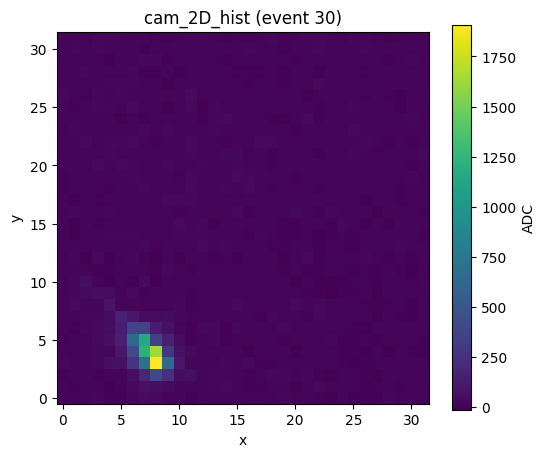

In [6]:
plt.figure(figsize=(6,5))
plt.imshow(data[event], origin='lower')
plt.xlabel("x"); plt.ylabel("y"); plt.colorbar(label="ADC")
plt.title("cam_2D_hist (event {:.0f})".format(event))
plt.show()

## Find the event timestamp

In [7]:
times = heap.read_pcap.read_tel_timestamps(data_file)

In [8]:
len(times)

209

In [9]:
times[event]

np.float64(1760943105.413461)

## Grab the corresponding pedestals

In [10]:
pedvar_file = data_file + ".pedvars"
peds = heap.read_pcap.read_tel_peds(pedvar_file)

## Plot the pedestals

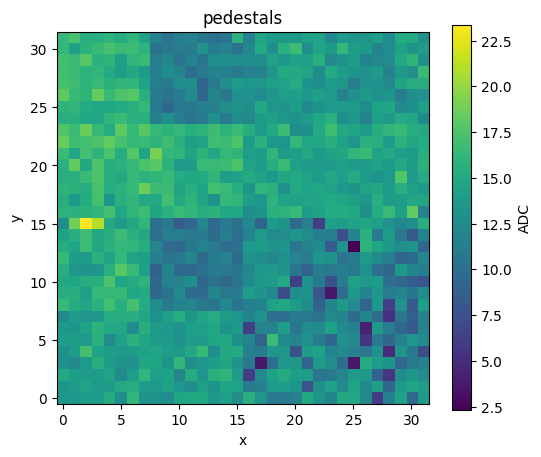

In [11]:
plt.figure(figsize=(6,5))
plt.imshow(peds, origin='lower')
plt.xlabel("x"); plt.ylabel("y"); plt.colorbar(label="ADC")
plt.title("pedestals")
plt.show()

## Pedestal subtraction

In [12]:
ped_subtracted_data = data-peds

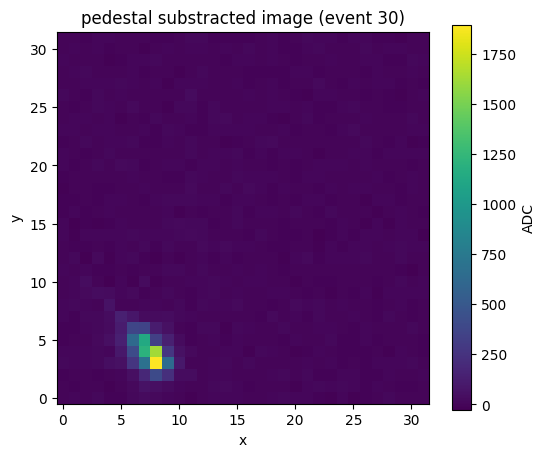

In [13]:
plt.figure(figsize=(6,5))
plt.imshow(ped_subtracted_data[event], origin='lower')
plt.xlabel("x"); plt.ylabel("y"); plt.colorbar(label="ADC")
plt.title("pedestal substracted image (event {:.0f})".format(event))
plt.show()

## Grab the pedvars to prepare for image cleaning

In [14]:
pedvars = heap.read_pcap.read_tel_pedvars(pedvar_file)

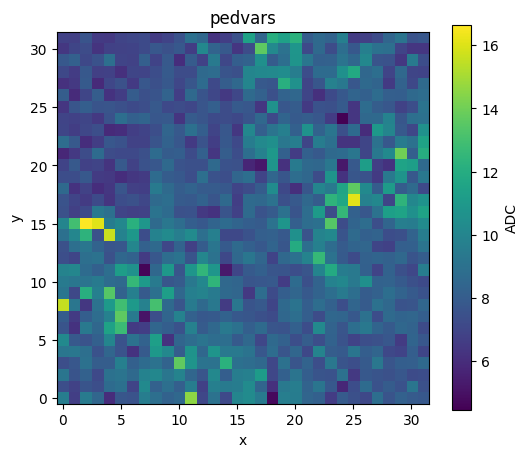

In [15]:
plt.figure(figsize=(6,5))
plt.imshow(pedvars, origin='lower')
plt.xlabel("x"); plt.ylabel("y"); plt.colorbar(label="ADC")
plt.title("pedvars".format(event))
plt.show()

## Threshold cleaning

In [16]:
cleaned_event, mask = heap.image_cleaning.threshold_clean(ped_subtracted_data[event], pedvars)

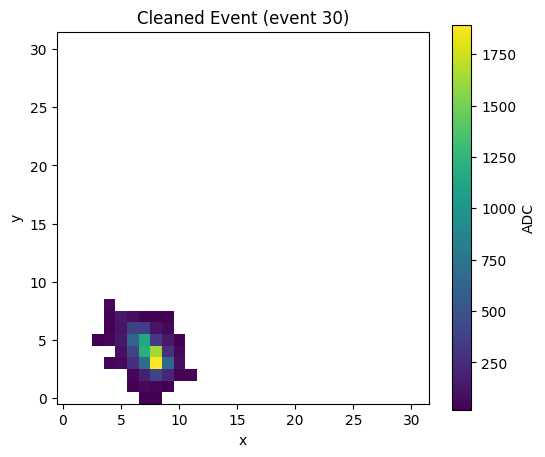

In [17]:
plt.figure(figsize=(6,5))
plt.imshow(cleaned_event, origin='lower')
plt.xlabel("x"); plt.ylabel("y"); plt.colorbar(label="ADC")
plt.title("Cleaned Event (event {:.0f})".format(event))
plt.show()

## Hillas parameterization

In [18]:
params=heap.parameterize.calc_params(cleaned_event)

In [19]:
params

{'N_pix': 46,
 'size': 12458.795789718628,
 'x_c': 7.353618153237133,
 'y_c': 3.97272218396063,
 's_xx': 1.3994999474176208,
 's_yy': 1.6510411285872264,
 's_xy': -0.6912964018613433,
 'length': 1.4926201118868565,
 'width': 0.9069874737810415,
 'miss': 13.640268292046125,
 'distance': 14.115299183560403,
 'alpha': 75.0933840345553,
 'phi': 309.8443541878947}

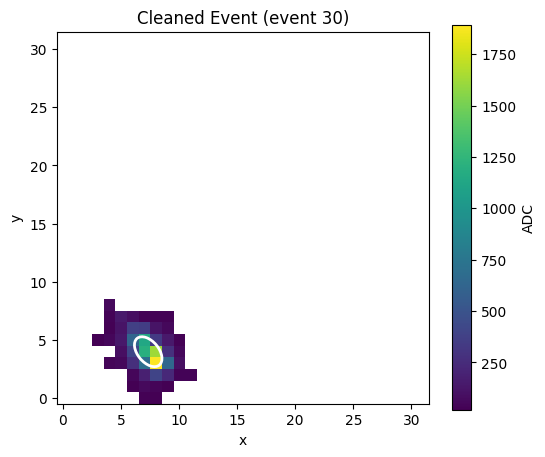

In [20]:
plt.figure(figsize=(6,5))
plt.imshow(cleaned_event, origin='lower')
ellipse = Ellipse(
    [params['x_c'], params['y_c']], 
    2*params['length'], 
    2*params['width'], 
    angle=params['phi'],
    facecolor='None',
    edgecolor='w',
    lw=2
)
ax = plt.gca()
ax.add_patch(ellipse)
plt.xlabel("x"); plt.ylabel("y"); plt.colorbar(label="ADC")
plt.title("Cleaned Event (event {:.0f})".format(event))
plt.show()